# Entrenamiento de Redes Neuronales - Covertype

Notebook que consume datos de la base de datos PostgreSQL (extraídos por Airflow),
realiza limpieza de datos y entrena múltiples modelos de redes neuronales
con diferentes arquitecturas (capas y neuronas).

Los modelos se suben a MinIO para ser consumidos por la API de inferencia.

In [1]:
import os
import io
import tempfile

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from minio import Minio

## 1. Conexión a la base de datos y carga de datos

In [2]:
engine = create_engine(
    f"postgresql+psycopg2://{os.environ['DATA_DB_USER']}:{os.environ['DATA_DB_PASSWORD']}"
    f"@{os.environ['DATA_DB_HOST']}:{os.environ['DATA_DB_PORT']}/{os.environ['DATA_DB_NAME']}"
)

# forest_training ya está limpia: sin nulos, sin duplicados,
# tipos numéricos correctos — producida por el DAG de Airflow.
df = pd.read_sql(
    "SELECT * FROM forest_training",
    engine,
)

# Eliminar columnas de metadatos generadas por el pipeline
df = df.drop(columns=["id", "inserted_at", "batch_id"], errors="ignore")

print(f"Total registros cargados: {len(df)}")
print(f"Columnas: {list(df.columns)}")
df.head()

Total registros cargados: 1509
Columnas: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type', 'Cover_Type']


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
0,2656,254,17,42,10,1532,178,249,207,1140,Commanche,C7202,1
1,3144,113,14,319,83,1082,243,226,109,1513,Commanche,C4758,1
2,2807,84,26,495,280,1165,246,185,52,1015,Commanche,C4758,1
3,2805,247,32,573,299,999,138,244,231,1719,Commanche,C7710,1
4,2899,43,9,190,19,1793,222,221,134,2221,Rawah,C7745,1


In [3]:
df.info()
print("\nEstadísticas descriptivas:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1509 entries, 0 to 1508
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Elevation                           1509 non-null   int64 
 1   Aspect                              1509 non-null   int64 
 2   Slope                               1509 non-null   int64 
 3   Horizontal_Distance_To_Hydrology    1509 non-null   int64 
 4   Vertical_Distance_To_Hydrology      1509 non-null   int64 
 5   Horizontal_Distance_To_Roadways     1509 non-null   int64 
 6   Hillshade_9am                       1509 non-null   int64 
 7   Hillshade_Noon                      1509 non-null   int64 
 8   Hillshade_3pm                       1509 non-null   int64 
 9   Horizontal_Distance_To_Fire_Points  1509 non-null   int64 
 10  Wilderness_Area                     1509 non-null   object
 11  Soil_Type                           1509 non-null   obje

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type
count,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000
mean,2854.420808,157.697150,14.798542,258.785951,48.964877,2170.521537,210.872101,222.748178,142.878065,1946.197482,1.665341
std,283.804019,111.470651,7.811046,198.362103,59.190198,1536.224843,28.355412,20.703225,39.449709,1372.952127,1.438389
min,1947.000000,0.000000,1.000000,0.000000,-90.000000,0.000000,68.000000,111.000000,0.000000,30.000000,1.000000
25%,2698.000000,62.000000,9.000000,108.000000,9.000000,966.000000,195.000000,212.000000,119.000000,977.000000,1.000000
50%,2897.000000,126.000000,14.000000,218.000000,31.000000,1753.000000,217.000000,226.000000,142.000000,1624.000000,1.000000
75%,3029.000000,261.000000,20.000000,361.000000,70.000000,3062.000000,232.000000,237.000000,170.000000,2448.000000,1.000000
max,3844.000000,360.000000,57.000000,1249.000000,496.000000,6873.000000,254.000000,254.000000,245.000000,6816.000000,6.000000


## 2. Exploración de datos

> **Nota:** la limpieza (eliminación de nulos, duplicados y valores físicamente imposibles)
> ya fue realizada por el DAG de Airflow en la tarea `clean_for_training`.
> Aquí solo se verifica la calidad y se visualizan distribuciones.

In [4]:
# Verificación de calidad — el DAG ya limpió los datos
print(f"Registros: {len(df)}")
print(f"\nValores nulos por columna:")
print(df.isnull().sum())
print(f"\nDistribución de Cover_Type:")
print(df["Cover_Type"].value_counts().sort_index())
print(f"\nTipos de datos:")
print(df.dtypes)

Registros: 1509

Valores nulos por columna:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area                       0
Soil_Type                             0
Cover_Type                            0
dtype: int64

Distribución de Cover_Type:
Cover_Type
1    1153
2     145
3      11
4      33
5      97
6      70
Name: count, dtype: int64

Tipos de datos:
Elevation                              int64
Aspect                                 int64
Slope                                  int64
Horizontal_Distance_To_Hydrology       int64
Vertical_Distance_To_Hydrology         int64
Horizontal_Distance_To_Roadways        int64
Hillshade_

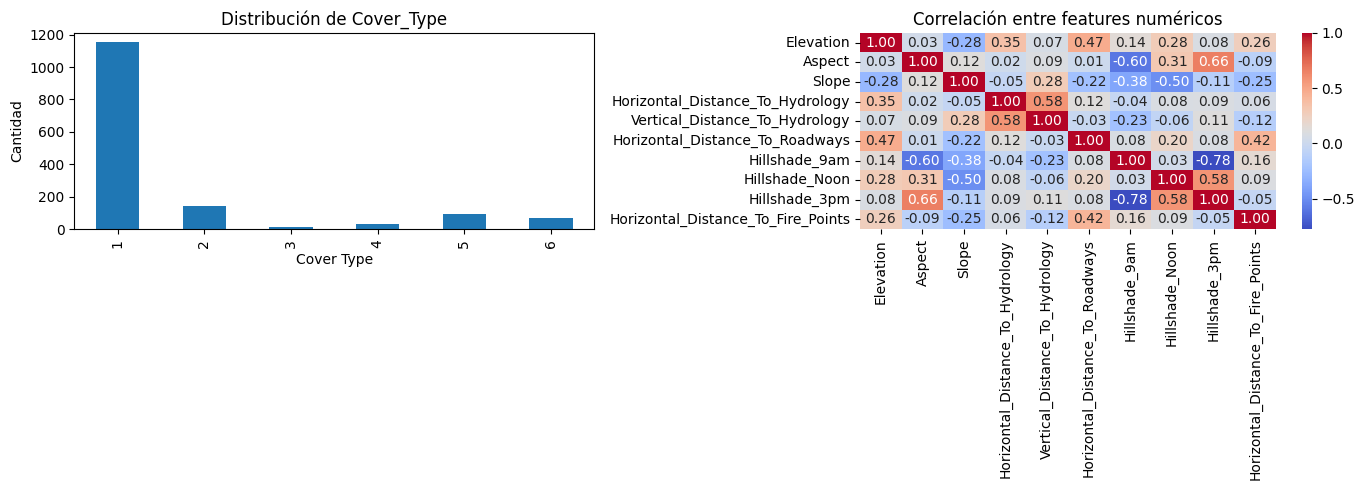

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Cover_Type"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Distribución de Cover_Type")
axes[0].set_xlabel("Cover Type")
axes[0].set_ylabel("Cantidad")

numeric_feature_cols = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]
sns.heatmap(df[numeric_feature_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlación entre features numéricos")

plt.tight_layout()
plt.show()

## 3. Preparación de datos para entrenamiento

In [6]:
NUMERIC_FEATURES = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]
CATEGORICAL_FEATURES = ["Wilderness_Area", "Soil_Type"]
TARGET = "Cover_Type"

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

# Split en 3: 60% train, 20% validación, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full,
)
print(f"Train: {len(X_train)} | Validación: {len(X_val)} | Test: {len(X_test)}")


def make_preprocessor():
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ])

Train: 905 | Validación: 302 | Test: 302


## 4. Entrenamiento de redes neuronales

Se entrenan 5 modelos MLP con diferentes arquitecturas variando capas y neuronas:

| Modelo | Arquitectura | Descripción |
|--------|-------------|-------------|
| `mlp_small` | (64,) | 1 capa, 64 neuronas |
| `mlp_medium` | (128, 64) | 2 capas, 128→64 neuronas |
| `mlp_large` | (256, 128, 64) | 3 capas, 256→128→64 neuronas |
| `mlp_deep` | (128, 128, 64, 32) | 4 capas, 128→128→64→32 neuronas |
| `mlp_wide` | (512, 256) | 2 capas anchas, 512→256 neuronas |

In [7]:
architectures = {
    "mlp_small":  (64,),
    "mlp_medium": (128, 64),
    "mlp_large":  (256, 128, 64),
    "mlp_deep":   (128, 128, 64, 32),
    "mlp_wide":   (512, 256),
}

results = {}

for name, hidden_layers in architectures.items():
    print(f"\n{'='*60}")
    print(f"Entrenando: {name} | Arquitectura: {hidden_layers}")
    print("=" * 60)

    pipeline = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("classifier", MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            max_iter=500,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
        )),
    ])
    pipeline.fit(X_train, y_train)

    # Evaluar en validación
    y_pred_val = pipeline.predict(X_val)
    acc_val = accuracy_score(y_val, y_pred_val)

    # Evaluar en test
    y_pred_test = pipeline.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred_test)

    results[name] = {
        "accuracy_val": acc_val,
        "accuracy_test": acc_test,
        "architecture": hidden_layers,
        "pipeline": pipeline,
    }

    print(f"Accuracy Validación: {acc_val:.4f}")
    print(f"Accuracy Test:       {acc_test:.4f}")
    print(f"\nClassification Report (Test):")
    print(classification_report(y_test, y_pred_test))


Entrenando: mlp_small | Arquitectura: (64,)
Accuracy Validación: 0.8377
Accuracy Test:       0.8113

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.84      0.99      0.90       231
           2       0.64      0.55      0.59        29
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         7
           5       0.25      0.05      0.09        19
           6       0.00      0.00      0.00        14

    accuracy                           0.81       302
   macro avg       0.29      0.27      0.26       302
weighted avg       0.72      0.81      0.75       302


Entrenando: mlp_medium | Arquitectura: (128, 64)


/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy Validación: 0.8775
Accuracy Test:       0.8543

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.91      0.99      0.95       231
           2       0.56      0.69      0.62        29
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         7
           5       0.29      0.11      0.15        19
           6       1.00      0.57      0.73        14

    accuracy                           0.85       302
   macro avg       0.46      0.39      0.41       302
weighted avg       0.81      0.85      0.83       302


Entrenando: mlp_large | Arquitectura: (256, 128, 64)


/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy Validación: 0.9007
Accuracy Test:       0.8642

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.93      0.97      0.95       231
           2       0.62      0.72      0.67        29
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         7
           5       0.31      0.26      0.29        19
           6       0.92      0.86      0.89        14

    accuracy                           0.86       302
   macro avg       0.46      0.47      0.47       302
weighted avg       0.84      0.86      0.85       302


Entrenando: mlp_deep | Arquitectura: (128, 128, 64, 32)


/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy Validación: 0.8709
Accuracy Test:       0.8642

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.90      1.00      0.94       231
           2       0.65      0.69      0.67        29
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         7
           5       0.56      0.26      0.36        19
           6       1.00      0.43      0.60        14

    accuracy                           0.86       302
   macro avg       0.52      0.40      0.43       302
weighted avg       0.83      0.86      0.84       302


Entrenando: mlp_wide | Arquitectura: (512, 256)


/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy Validación: 0.8841
Accuracy Test:       0.8609

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.91      0.99      0.95       231
           2       0.68      0.59      0.63        29
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         7
           5       0.39      0.37      0.38        19
           6       1.00      0.50      0.67        14

    accuracy                           0.86       302
   macro avg       0.50      0.41      0.44       302
weighted avg       0.83      0.86      0.84       302



/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/app/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 5. Comparación de resultados

    Modelo       Arquitectura  Acc. Validación  Acc. Test
 mlp_large     (256, 128, 64)         0.900662   0.864238
  mlp_deep (128, 128, 64, 32)         0.870861   0.864238
  mlp_wide         (512, 256)         0.884106   0.860927
mlp_medium          (128, 64)         0.877483   0.854305
 mlp_small              (64,)         0.837748   0.811258


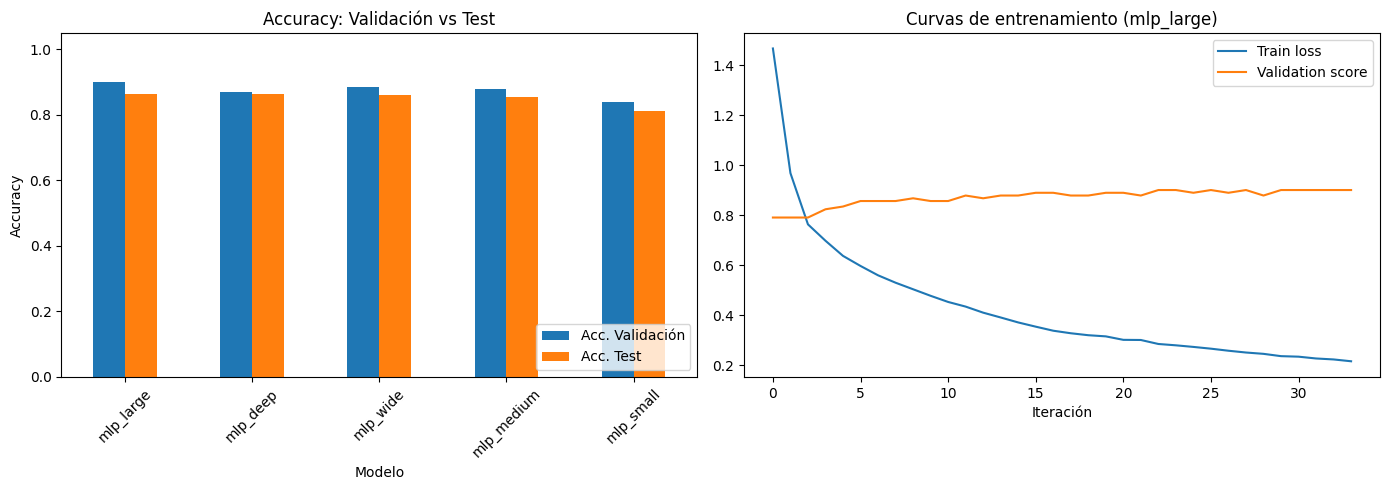

In [8]:
results_df = pd.DataFrame([
    {
        "Modelo": name,
        "Arquitectura": str(info["architecture"]),
        "Acc. Validación": info["accuracy_val"],
        "Acc. Test": info["accuracy_test"],
    }
    for name, info in results.items()
]).sort_values("Acc. Test", ascending=False)

print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy validación vs test por modelo
results_df.plot(x="Modelo", y=["Acc. Validación", "Acc. Test"], kind="bar", ax=axes[0])
axes[0].set_title("Accuracy: Validación vs Test")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(loc="lower right")

# Curvas de pérdida del mejor modelo
best_model_name = results_df.iloc[0]["Modelo"]
best_clf = results[best_model_name]["pipeline"].named_steps["classifier"]
axes[1].plot(best_clf.loss_curve_, label="Train loss")
if best_clf.validation_scores_:
    axes[1].plot(best_clf.validation_scores_, label="Validation score")
axes[1].set_title(f"Curvas de entrenamiento ({best_model_name})")
axes[1].set_xlabel("Iteración")
axes[1].legend()

plt.tight_layout()
plt.show()

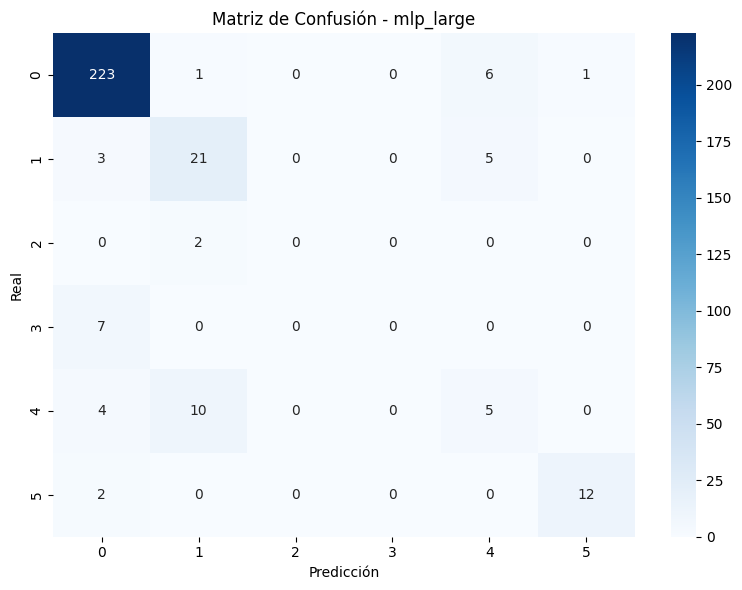

In [9]:
# Matriz de confusión del mejor modelo
best_pipeline = results[best_model_name]["pipeline"]
y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de Confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

## 6. Subir modelos a MinIO

In [10]:
minio_client = Minio(
    os.environ["MINIO_ENDPOINT"],
    access_key=os.environ["MINIO_ACCESS_KEY"],
    secret_key=os.environ["MINIO_SECRET_KEY"],
    secure=False,
)

bucket = os.environ.get("MINIO_BUCKET", "models")
if not minio_client.bucket_exists(bucket):
    minio_client.make_bucket(bucket)

for name, info in results.items():
    buffer = io.BytesIO()
    joblib.dump(info["pipeline"], buffer)
    buffer.seek(0)
    object_name = f"{name}.joblib"
    minio_client.put_object(bucket, object_name, buffer, length=buffer.getbuffer().nbytes)
    print(f"Subido: {object_name} ({buffer.getbuffer().nbytes / 1024:.1f} KB)")

print(f"\n{len(results)} modelos subidos a MinIO (bucket: {bucket})")
print("Usa POST /reload en la API para cargar los nuevos modelos.")

Subido: mlp_small.joblib (92.6 KB)
Subido: mlp_medium.joblib (357.2 KB)
Subido: mlp_large.joblib (1269.6 KB)
Subido: mlp_deep.joblib (789.0 KB)
Subido: mlp_wide.joblib (3691.8 KB)

5 modelos subidos a MinIO (bucket: models)
Usa POST /reload en la API para cargar los nuevos modelos.
